## Exercise 7
training a decision tree on the make_moons dataset 

In [37]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
state = 20
X, y = make_moons(n_samples = 10000, noise = 0.4, random_state = state)


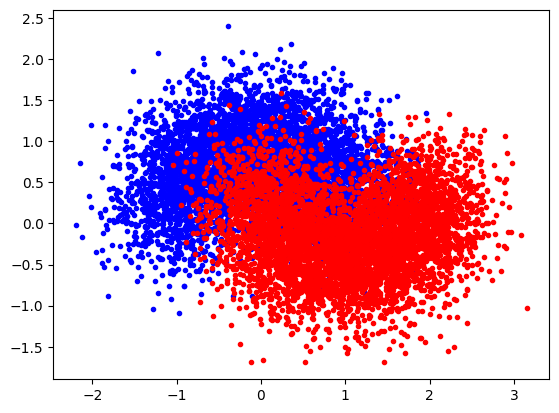

In [38]:
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.show()

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = state)

parameters = {
    'max_leaf_nodes' : [5, 10, 20],
    'max_depth' : [3, 4, 5, 6]
}
tree_clf = GridSearchCV(DecisionTreeClassifier(random_state = state), parameters)
tree_clf.fit(X_train, y_train)


GridSearchCV(estimator=DecisionTreeClassifier(random_state=20),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'max_leaf_nodes': [5, 10, 20]})

In [41]:
from sklearn.metrics import accuracy_score
y_pred = tree_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.859

## Exercise 8
Growing a forest

In [43]:
from sklearn.model_selection import ShuffleSplit
from scipy.stats import mode
import numpy as np

shuffler = ShuffleSplit(n_splits = 1000, train_size = 100, random_state = state)
trees = []
for i, (train_index, test_index) in enumerate(shuffler.split(X_train, y_train)):
    tree_clf_x = DecisionTreeClassifier(max_depth = 3, max_leaf_nodes = 5, random_state = state)
    tree_clf_x.fit(X_train[train_index], y_train[train_index])
    trees.append(tree_clf_x)


predictions = []
length = len(trees)
for i, tree_clf_x in enumerate(trees):
    print(f'Tree {i} out of {length}')
    predictions.append(tree_clf_x.predict(X_test))
predictions = np.array(predictions)
y_predictions = mode(predictions, axis = 0)[0]
acc = accuracy_score(y_test, y_predictions)



Tree 0 out of 1000
Tree 1 out of 1000
Tree 2 out of 1000
Tree 3 out of 1000
Tree 4 out of 1000
Tree 5 out of 1000
Tree 6 out of 1000
Tree 7 out of 1000
Tree 8 out of 1000
Tree 9 out of 1000
Tree 10 out of 1000
Tree 11 out of 1000
Tree 12 out of 1000
Tree 13 out of 1000
Tree 14 out of 1000
Tree 15 out of 1000
Tree 16 out of 1000
Tree 17 out of 1000
Tree 18 out of 1000
Tree 19 out of 1000
Tree 20 out of 1000
Tree 21 out of 1000
Tree 22 out of 1000
Tree 23 out of 1000
Tree 24 out of 1000
Tree 25 out of 1000
Tree 26 out of 1000
Tree 27 out of 1000
Tree 28 out of 1000
Tree 29 out of 1000
Tree 30 out of 1000
Tree 31 out of 1000
Tree 32 out of 1000
Tree 33 out of 1000
Tree 34 out of 1000
Tree 35 out of 1000
Tree 36 out of 1000
Tree 37 out of 1000
Tree 38 out of 1000
Tree 39 out of 1000
Tree 40 out of 1000
Tree 41 out of 1000
Tree 42 out of 1000
Tree 43 out of 1000
Tree 44 out of 1000
Tree 45 out of 1000
Tree 46 out of 1000
Tree 47 out of 1000
Tree 48 out of 1000
Tree 49 out of 1000
Tree 50 ou

In [44]:
acc

0.862